In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import torch.nn.functional as F
import pandas as pd
from PIL import Image
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

# Folder structure

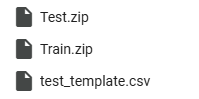

In [ ]:
!unzip /content/Train.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/images/image_1.png  
  inflating: Training/images/image_10.png  
  inflating: Training/images/image_100.png  
  inflating: Training/images/image_1000.png  
  inflating: Training/images/image_1001.png  
  inflating: Training/images/image_1002.png  
  inflating: Training/images/image_1003.png  
  inflating: Training/images/image_1004.png  
  inflating: Training/images/image_1005.png  
  inflating: Training/images/image_1006.png  
  inflating: Training/images/image_1007.png  
  inflating: Training/images/image_1008.png  
  inflating: Training/images/image_1009.png  
  inflating: Training/images/image_101.png  
  inflating: Training/images/image_1010.png  
  inflating: Training/images/image_1011.png  
  inflating: Training/images/image_1012.png  
  inflating: Training/images/image_1013.png  
  inflating: Training/images/image_1014.png  
  inflating: Training/images/image_1015.png  
  inflating: Training/images/image_1

In [ ]:
!unzip /content/Test.zip

Archive:  /content/Test.zip
   creating: Test/
   creating: Test/images/
  inflating: Test/images/image_0.png  
  inflating: Test/images/image_1.png  
  inflating: Test/images/image_10.png  
  inflating: Test/images/image_100.png  
  inflating: Test/images/image_101.png  
  inflating: Test/images/image_102.png  
  inflating: Test/images/image_103.png  
  inflating: Test/images/image_104.png  
  inflating: Test/images/image_105.png  
  inflating: Test/images/image_106.png  
  inflating: Test/images/image_107.png  
  inflating: Test/images/image_108.png  
  inflating: Test/images/image_109.png  
  inflating: Test/images/image_11.png  
  inflating: Test/images/image_110.png  
  inflating: Test/images/image_111.png  
  inflating: Test/images/image_112.png  
  inflating: Test/images/image_113.png  
  inflating: Test/images/image_114.png  
  inflating: Test/images/image_115.png  
  inflating: Test/images/image_116.png  
  inflating: Test/images/image_117.png  
  inflating: Test/images/image_

# Dataset

In [ ]:
def onehot_encode(label):
    if label == 0:
        return [1, 0, 0]
    elif label == 1:
        return [0, 1, 0]
    else :
        return [0, 0, 1]

class CustomDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        self.columns_to_encode = ['obj_1_label_0', 'obj_2_label_0', 'obj_3_label_0', 'obj_4_label_0', 'obj_5_label_0']
        for col in self.columns_to_encode:
            onehot = self.annotations[col].apply(onehot_encode)
            self.annotations[col] = onehot

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        img_path = os.path.join(self.root_dir, self.annotations.iloc[index, 0])
        image = Image.open(img_path).convert('RGB')
        class_label = torch.tensor(self.annotations[self.columns_to_encode].iloc[index, :], dtype=torch.float32)

        posi_label = self.annotations.iloc[index, 1:].drop(self.columns_to_encode)
        posi_label = torch.tensor(posi_label, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, class_label,posi_label

class CustomTestDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        fname=self.annotations.iloc[index, 0]
        img_path = os.path.join(self.root_dir, fname)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image,fname

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert image to PyTorch tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) #Normalize the image
])
dataset=CustomDataset('/content/Training/labels.csv','Training/images',transform)
test_dataset=CustomTestDataset('/content/test_template.csv','Test/images',transform)
test_result = pd.read_csv('/content/test_template.csv', index_col=0)

# Model

In [ ]:
class TwoHeadCNN(nn.Module):
    def __init__(self, num_classes=3, num_obj=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 16 * 16, 128) # Adjust input size based on image dimensions and pooling
        self.relu3 = nn.ReLU()

        # Classification Head
        self.classifier = nn.Linear(128, num_obj*num_classes)

        # Bounding Box Regression Head (cx, cy, w, h per object)
        self.bbox_regressor = nn.Linear(128, num_obj * 4) # Assuming a maximum of 5 objects


    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 32 * 16 * 16) # Adjust input size
        x = self.relu3(self.fc1(x))

        # Classification output
        class_output = self.classifier(x)

        #Bounding box output
        bbox_output = self.bbox_regressor(x)

        return class_output, bbox_output


In [ ]:
def train(model, train_loader, criterion_cls, criterion_bbox, optimizer, device, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss_cls = 0.0
        running_loss_bbox = 0.0
        for images, obj_class, obj_posi in train_loader:
            images = images.to(device)
            # Split labels into classification and bounding box targets
            cls_labels = obj_class.view(-1,15).to(device)  # Assuming the first element is the class label
            bbox_labels = obj_posi.to(device)      # The rest are bounding box coordinates


            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            class_outputs, bbox_outputs = model(images)


            # Calculate losses
            loss_cls = criterion_cls(class_outputs, cls_labels)
            loss_bbox = criterion_bbox(F.sigmoid(bbox_outputs), bbox_labels)

            # Combine losses (adjust weights as needed)
            loss = loss_cls + loss_bbox

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Update running losses
            running_loss_cls += loss_cls.item()
            running_loss_bbox += loss_bbox.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss (Classification): {running_loss_cls / len(train_loader)}, Loss (Bounding Box): {running_loss_bbox / len(train_loader)}")
    return running_loss_cls / len(train_loader), running_loss_bbox / len(train_loader)


# Train

In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Determine the number of workers for the DataLoader based on the available CPU cores
num_workers = os.cpu_count()


# Use the determined number of workers when creating the DataLoader
train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=num_workers)



In [ ]:
# Hyperparameters
batch_size = 256
learning_rate = 0.001
num_epochs = 50

# Initialize the model, criterion, and optimizer
model = TwoHeadCNN( num_classes=3, num_obj=5).to(device) # Assuming 2 classes (circle, rectangle)
criterion_cls = nn.BCEWithLogitsLoss()
criterion_bbox = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
train(model, train_loader, criterion_cls, criterion_bbox, optimizer, device, epochs=num_epochs)

Epoch 1/50, Loss (Classification): 0.39727298146600176, Loss (Bounding Box): 0.0349945496340656
Epoch 2/50, Loss (Classification): 0.351775379507405, Loss (Bounding Box): 0.026571435818246975
Epoch 3/50, Loss (Classification): 0.32999437345061333, Loss (Bounding Box): 0.024930606708879685
Epoch 4/50, Loss (Classification): 0.3077107385085647, Loss (Bounding Box): 0.023719273317771353
Epoch 5/50, Loss (Classification): 0.2870318604882356, Loss (Bounding Box): 0.022638411409441072
Epoch 6/50, Loss (Classification): 0.2629656222215883, Loss (Bounding Box): 0.02106475475938267
Epoch 7/50, Loss (Classification): 0.23804722451100682, Loss (Bounding Box): 0.01990658305229465
Epoch 8/50, Loss (Classification): 0.21194106966826567, Loss (Bounding Box): 0.01875780802220106
Epoch 9/50, Loss (Classification): 0.18572371163565643, Loss (Bounding Box): 0.017619153051666774
Epoch 10/50, Loss (Classification): 0.15475894885647828, Loss (Bounding Box): 0.01672643415368856
Epoch 11/50, Loss (Classificat

(0.0002398319230700404, 0.004022010188300613)

# Test

In [ ]:
# prompt: revise eval to concat batch_output to be all_output and fname to be all_filename
def eval(model, test_loader):
    all_output = []
    all_filename = []
    with torch.no_grad(): # Disable gradient calculations for evaluation
        model.eval()
        for images, fname in test_loader:
            images = images.to(device)
            class_outputs, bbox_outputs = model(images)

            # Calculate losses
            class_outputs = F.sigmoid(class_outputs)
            bbox_outputs = F.sigmoid(bbox_outputs)
            batch_output = torch.tensor([]).to(device)
            for i in range(5):
                class_output = torch.argmax(class_outputs[:,i*3:(i+1)*3], dim=1) #added dim=1 to get correct argmax
                class_output = torch.where(class_output == 2, torch.tensor(-1).to(device), class_output).int() # Use torch.where for tensor operations
                bbox_output = bbox_outputs[:,i*4:(i+1)*4]
                combined_output = torch.cat((class_output.unsqueeze(1), bbox_output), dim=1)
                if batch_output.nelement() == 0:  # If batch_output is empty
                    batch_output = combined_output
                else:
                    batch_output = torch.cat([batch_output, combined_output], dim=1)  # Concatenate along dim=0

            all_output.extend(batch_output.tolist())
            all_filename.extend(fname) # Extend the list with filenames from the current batch

    return all_filename, np.array(all_output)


In [ ]:
all_filename, all_output=eval(model, test_loader)

In [ ]:
for i in range(len(all_filename)):
    test_result.loc[all_filename[i], :] = all_output[i]
test_result.to_csv('test_beseline.csv')